In [2]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from pprint import pprint
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import VotingClassifier
from sklearn.compose import ColumnTransformer

In [3]:
# Load datasets
df1 = pd.read_csv("observations2.tsv", sep='\t')
df2 = pd.read_csv("patients2.tsv", sep='\t')
df3 = pd.read_csv("stations2.tsv", sep='\t')

In [4]:
# join data on longitude and latitude
keys = ['longitude', 'latitude']
df = pd.merge(df1, df3, on=keys, how='inner')
df


,SPO2,HR,PI,RR,ETCO2,FIO2,PRV,BP,ST,MAI,...,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude,code,station,location
0,97.287434,72.727986,13.660737,15.755854,39.737731,49.035774,87.868263,99.655904,35.376585,7.955277,...,51.192423,38.744548,0.229549,25.836222,1.0,35.06544,1.049450,DZ,Frenda,Africa/Algiers
1,98.537124,73.435702,4.453073,15.925616,40.015592,76.884562,76.449362,99.778323,36.578250,10.290540,...,54.580531,44.654611,0.229253,22.657638,1.0,23.56540,119.586270,TW,Magong,Asia/Taipei
2,99.126826,74.484895,14.230313,16.793470,38.773612,65.426955,76.714834,111.320081,34.413950,7.645887,...,50.899240,36.904112,0.221017,30.960610,1.0,48.79325,2.292750,FR,Fontenay-aux-Roses,Europe/Paris
3,98.699062,72.789517,3.295218,16.537063,40.458715,54.228426,84.446027,100.136492,36.216960,12.364709,...,37.521845,65.873715,0.263626,34.126183,1.0,60.02427,30.284910,RU,Kolomyagi,Europe/Moscow
4,96.775490,81.687039,4.805640,15.542213,38.756204,67.977808,127.867499,104.221144,35.304788,13.230194,...,64.705098,52.729143,0.219447,21.006023,0.0,-5.85746,144.230580,PG,Mount Hagen,Pacific/Port_Moresby
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12067,97.053526,79.517234,9.261270,14.736852,39.620976,57.772883,116.205787,105.639263,35.526930,8.452890,...,45.838061,63.403682,0.210694,23.844717,1.0,1.65610,103.603200,MY,Kulai,Asia/Kuala_Lumpur
12068,97.539191,86.483856,8.669419,17.095280,39.822356,59.610411,131.395847,100.085537,34.911060,9.644136,...,56.692310,51.751882,0.203792,32.208986,0.0,49.73843,13.373637,CZ,Plzeň,Europe/Prague
12069,97.792523,81.619683,11.937089,15.706645,42.517437,48.626094,67.856358,108.645851,34.993891,8.981748,...,60.316394,31.344551,0.241141,35.746108,1.0,28.15112,-82.461480,US,Lutz,America/New_York
12070,97.221186,81.171025,6.265514,16.152893,39.785292,36.938033,133.152911,104.618399,34.828797,7.306094,...,59.732007,27.343396,0.258182,33.449893,0.0,50.80019,7.207690,DE,Siegburg,Europe/Berlin


In [5]:
#
TARGET = 'oximetry'

DROP_COLS = [
    'location'
]

X = df.drop(columns=[TARGET] + DROP_COLS)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training size: {X_train.shape}, Test size: {X_test.shape}")

Training size: (8450, 24), Test size: (3622, 24)


In [6]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """
    Sklearn-compatible transformer for outlier clipping (winsorization),
    supporting per-column method selection (IQR or SD).
    """

    def __init__(self, methods_dict, sd_threshold=3, lower_pct=0.05, upper_pct=0.95, softness=0.99):
        """
        methods_dict: dict, e.g. {"HR": "SD", "SPO2": "IQR"}
        sd_threshold: cutoff for z-score when using SD
        lower_pct, upper_pct: quantile bounds used for soft winsorization
        softness: smoothing factor (0=no smoothing, 1=full)
        """
        self.methods_dict = methods_dict
        self.sd_threshold = sd_threshold
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct
        self.softness = softness

    def fit(self, X, y=None):
        """Compute winsorization bounds from TRAIN data only."""
        X = pd.DataFrame(X).copy()
        self.bounds_ = {}

        for col, method in self.methods_dict.items():
            data = X[col].dropna()
            if len(data) < 5:
                self.bounds_[col] = None
                continue

            # Hard bounds (IQR or SD)
            if method == "IQR":
                Q1, Q3 = data.quantile([0.25, 0.75])
                IQR = Q3 - Q1
                lower_hard = Q1 - 1.5 * IQR
                upper_hard = Q3 + 1.5 * IQR

            elif method == "SD":
                mean, std = data.mean(), data.std(ddof=1)
                lower_hard = mean - self.sd_threshold * std
                upper_hard = mean + self.sd_threshold * std

            else:
                raise ValueError(f"Unknown method {method}. Use 'IQR' or 'SD'.")

            # Soft clipping bounds
            lower_soft, upper_soft = data.quantile([self.lower_pct, self.upper_pct])

            self.bounds_[col] = {
                "lower_soft": lower_soft,
                "upper_soft": upper_soft,
                "lower_hard": lower_hard,
                "upper_hard": upper_hard
            }

        return self

    def transform(self, X):
        """Apply winsorization using bounds computed in fit()."""
        X = pd.DataFrame(X).copy()

        for col, bounds in self.bounds_.items():
            if bounds is None or col not in X.columns:
                continue

            ls, us = bounds["lower_soft"], bounds["upper_soft"]

            X[col] = np.where(
                X[col] < ls,
                ls + self.softness * (X[col] - ls),
                X[col]
            )
            X[col] = np.where(
                X[col] > us,
                us - self.softness * (us - X[col]),
                X[col]
            )

        return X


In [7]:
WINSOR_METHODS = {
    'SPO2': 'IQR',
    'HR': 'SD',
    'PI': 'IQR',
    'RR': 'SD',
    'FIO2': 'SD',
    'ETCO2': 'IQR',
    'MAI': 'IQR',
    'PRV': 'SD',
    'BP': 'SD',
    'ST': 'SD',
    'CO': 'IQR',
    'PVI': 'SD',
    'Hb level': 'SD',
    'SV': 'IQR',
    'Blood Flow Index': 'SD',
    'PPG waveform features': 'SD',
    'Signal Quality Index': 'SD',
    'Respiratory effort': 'SD',
    'O₂ extraction ratio': 'IQR',
    'SNR': 'IQR',
    'latitude': 'IQR',
    'longitude': 'IQR'
}
winsorizer = Winsorizer(methods_dict=WINSOR_METHODS)

In [8]:
STANDARD_NUM = [
    'HR','RR','FIO2','PRV','BP','PVI','Hb level',
    'Blood Flow Index','PPG waveform features',
    'Signal Quality Index','Respiratory effort'
]

ROBUST_NUM = [
    'SPO2','PI','ETCO2','ST','MAI','SV','latitude','longitude'
]

POWER_NUM = ['CO']

QUANT_NUM = ['O₂ extraction ratio', 'SNR']

LOW_CARD_CAT_COLS = [
    'code'        # 107 levels
]

HIGH_CARD_CAT_COLS = [
    'station'     # 552 levels
]

In [9]:
# NUMERIC PIPELINES

from sklearn.impute import SimpleImputer
from category_encoders.leave_one_out import LeaveOneOutEncoder

standard_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

robust_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

power_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])

quantile_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("quantile", QuantileTransformer(output_distribution="normal", random_state=42)),
    ("scaler", StandardScaler())
])


# CATEGORICAL PIPELINES

low_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

high_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("leaveoneout", LeaveOneOutEncoder())
])



In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("winsor", winsorizer, list(WINSOR_METHODS.keys())), 
        ("num_standard", standard_numeric_pipeline, STANDARD_NUM),
        ("num_robust", robust_numeric_pipeline, ROBUST_NUM),
        ("num_power", power_numeric_pipeline, POWER_NUM),
        ("num_quantile", quantile_numeric_pipeline, QUANT_NUM), 
        ("lowcat", low_card_pipeline, LOW_CARD_CAT_COLS),
        ("highcat", high_card_pipeline, HIGH_CARD_CAT_COLS),
    ],
    remainder="drop"
)

In [11]:
#since wrapper model rfe is really time-consumming we replace him with randomForest less complex but still relatively eficient

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel


selector = SelectFromModel(
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    max_features=10
)


preprocessed_selector = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", selector)
])

X_train_processed = preprocessed_selector.fit_transform(X_train, y_train)
X_test_processed  = preprocessed_selector.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(8450, 10)
(3622, 10)


In [12]:
X_train_np = X_train_processed.values if hasattr(X_train_processed, "values") else X_train_processed
y_train_np = y_train.values.ravel() if hasattr(y_train, "values") else y_train

X_test_np = X_test_processed.values if hasattr(X_test_processed, "values") else X_test_processed
y_test_np = y_test.values.ravel() if hasattr(y_test, "values") else y_test

## ID3

ID3 is simple and clasical algorithm for building decision trees.It constructs a tree by repeatedly selecting the attribute that provides the highest information gain, which is computed using entropy from information theory. The resulting tree is a set of decision rules that can classify new examples based on patterns learned from the training data.

In [13]:
# function to calculate the entropy
def entropy(y):
    """
    Vypočíta entropiu cieľovej premenné y.
    y: 1D numpy array s triedami
    """
    values, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))  # +1e-9 aby sa predišlo log(0)

def information_gain(y, x):
    
    
    H_y = entropy(y)
    
    
    values, counts = np.unique(x, return_counts=True)
    
    # entropia po splitu
    H_cond = 0
    for v, c in zip(values, counts):
        y_v = y[x == v]  # podmnožina y, kde x = v
        H_cond += (c / len(y)) * entropy(y_v)
    
    return H_y - H_cond

In [14]:
#id3 algorithm
def id3(X, y, depth=0, max_depth=3):
    if np.all(y == y[0]):
        return {"type": "leaf", "class": y[0]}
    
    if depth >= max_depth or X.shape[1] == 0:
        values, counts = np.unique(y, return_counts=True)
        majority = values[np.argmax(counts)]
        return {"type": "leaf", "class": majority}

    best_index = None
    best_gain = -np.inf
    for i in range(X.shape[1]):
        gain = information_gain(y, X[:, i])
        if gain > best_gain:
            best_gain = gain
            best_index = i

    # if no attribute provides gain, create leaf with majority
    if best_index is None or best_gain <= 0:
        values, counts = np.unique(y, return_counts=True)
        majority = values[np.argmax(counts)]
        return {"type": "leaf", "class": majority}

    node = {"type": "node", "attribute": best_index, "children": {}}
    values = np.unique(X[:, best_index])
    for value in values:
        mask = X[:, best_index] == value
        X_subset = X[mask]
        y_subset = y[mask]

        if len(y_subset) == 0:
            values_all, counts_all = np.unique(y, return_counts=True)
            majority = values_all[np.argmax(counts_all)]
            child = {"type": "leaf", "class": majority}
        else:
            child = id3(X_subset, y_subset, depth+1, max_depth=max_depth)

        node["children"][value] = child

    return node

In [15]:
def predict(tree, x):
    if tree["type"] == "leaf":
        return tree["class"]
    
    attr = tree["attribute"]
    value = x[attr]
    
    if value in tree["children"]:
        return predict(tree["children"][value], x)
    
    # fallback if unseen value
    child_classes = [c["class"] for c in tree["children"].values() if c["type"]=="leaf"]
    if child_classes:
        return max(set(child_classes), key=child_classes.count)
    return None

In [16]:

max_depth = 5

tree = id3(X_train_np, y_train_np, depth=0, max_depth=max_depth)


In [17]:
y_pred_train = np.array([predict(tree, row) for row in X_train_np])

In [18]:
# predictions
y_pred = np.array([predict(tree, row) for row in X_test_np])

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

print("TRAIN accuracy:", accuracy_score(y_train_np, y_pred_train))
print("TRAIN precision (macro):", precision_score(y_train_np, y_pred_train, average='macro'))
print("TRAIN recall (macro):", recall_score(y_train_np, y_pred_train, average='macro'))
print("TRAIN confusion:\n", confusion_matrix(y_train_np, y_pred_train))

print()
print("TEST accuracy:", accuracy_score(y_test_np, y_pred))
print("TEST precision (macro):", precision_score(y_test_np, y_pred, average='macro'))
print("TEST recall (macro):", recall_score(y_test_np, y_pred, average='macro'))
print("TEST confusion:\n", confusion_matrix(y_test_np, y_pred))

TRAIN accuracy: 1.0
TRAIN precision (macro): 1.0
TRAIN recall (macro): 1.0
TRAIN confusion:
 [[3435    0]
 [   0 5015]]

TEST accuracy: 0.6032578685808946
TEST precision (macro): 0.7996374790853318
TEST recall (macro): 0.5122199592668024
TEST confusion:
 [[  36 1437]
 [   0 2149]]


As we can see based on Train accuracy is 1.0 so the model is clearly overfit. However on the test set of data, our model is doing poorly- accuracy just ~ 0.60. Although precision is relatively high, it is because our model is taught to predict in vast majority of times that predicted value is 1 and in just 36 time out of 1437 our model predicts 0 correctly - precision of 0 would be just appr. 0.024. It is because our id3 classifier is for categorical data not numerical. We need to modificate our code using treshold to fix that

In [20]:
def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))


# ---------- Information Gain for categorical ----------
def information_gain_categorical(y, x):
    H_before = entropy(y)
    values, counts = np.unique(x, return_counts=True)

    H_after = 0
    for v, c in zip(values, counts):
        y_subset = y[x == v]
        H_after += (c / len(y)) * entropy(y_subset)

    return H_before - H_after


# ---------- Information Gain for numeric threshold ----------
def information_gain_numeric(y, x, threshold):
    left_mask = x <= threshold
    right_mask = x > threshold

    if left_mask.sum() == 0 or right_mask.sum() == 0:
        return -np.inf

    H_before = entropy(y)

    H_left = entropy(y[left_mask])
    H_right = entropy(y[right_mask])

    w_left = left_mask.sum() / len(y)
    w_right = right_mask.sum() / len(y)

    H_after = w_left * H_left + w_right * H_right

    return H_before - H_after

In [21]:
def candidate_thresholds(x):
    """Return midpoints between sorted unique values."""
    uniq = np.unique(x)
    if len(uniq) <= 1:
        return []
    return (uniq[:-1] + uniq[1:]) / 2.0

In [22]:
def id3(X, y, depth=0, max_depth=3):
    # Pure class → leaf
    if np.all(y == y[0]):
        return {"type": "leaf", "class": y[0]}

    # Max depth or no columns left → leaf
    if depth >= max_depth or X.shape[1] == 0:
        values, counts = np.unique(y, return_counts=True)
        majority = values[np.argmax(counts)]
        return {"type": "leaf", "class": majority}

    best_index = None
    best_gain = -float('inf')
    best_threshold = None
    best_is_numeric = False

    # --- evaluate all attributes ---
    for i in range(X.shape[1]):
        column = X[:, i]

        # numeric → try thresholds
        if np.issubdtype(column.dtype, np.number):
            for t in candidate_thresholds(column):
                gain = information_gain_numeric(y, column, t)
                if gain > best_gain:
                    best_gain = gain
                    best_index = i
                    best_threshold = t
                    best_is_numeric = True

        # categorical → standard IG
        else:
            gain = information_gain_categorical(y, column)
            if gain > best_gain:
                best_gain = gain
                best_index = i
                best_threshold = None
                best_is_numeric = False

    # leaf
    if best_index is None or best_gain <= 0:
        values, counts = np.unique(y, return_counts=True)
        majority = values[np.argmax(counts)]
        return {"type": "leaf", "class": majority}

    # ---------- numeric split ----------
    if best_is_numeric:
        xcol = X[:, best_index]
        left_mask = xcol <= best_threshold
        right_mask = xcol > best_threshold

        left_child = id3(X[left_mask], y[left_mask], depth+1, max_depth)
        right_child = id3(X[right_mask], y[right_mask], depth+1, max_depth)

        return {
            "type": "node",
            "attribute": best_index,
            "numeric": True,
            "threshold": best_threshold,
            "children": {
                "<=": left_child,
                ">": right_child
            }
        }

    # ---------- categorical split ----------
    node = {
        "type": "node",
        "attribute": best_index,
        "numeric": False,
        "threshold": None,
        "children": {}
    }

    values = np.unique(X[:, best_index])
    for v in values:
        mask = X[:, best_index] == v
        if mask.sum() == 0:
            # majority fallback
            values_all, counts_all = np.unique(y, return_counts=True)
            majority = values_all[np.argmax(counts_all)]
            child = {"type": "leaf", "class": majority}
        else:
            child = id3(X[mask], y[mask], depth+1, max_depth)
        node["children"][v] = child

    return node

In [23]:
def predict(tree, x):
    if tree["type"] == "leaf":
        return tree["class"]

    attr = tree["attribute"]

    # numeric split
    if tree["numeric"]:
        if x[attr] <= tree["threshold"]:
            return predict(tree["children"]["<="], x)
        else:
            return predict(tree["children"][">"], x)

    # categorical split
    value = x[attr]
    if value in tree["children"]:
        return predict(tree["children"][value], x)
    else:
        # fallback: pick majority from children
        classes = []
        for child in tree["children"].values():
            if child["type"] == "leaf":
                classes.append(child["class"])
        # return most common
        if classes:
            return max(set(classes), key=classes.count)
        return None

In [24]:
tree = id3(X_train_np, y_train_np, max_depth=5)

In [25]:
y_pred = np.array([predict(tree, row) for row in X_test_np])

In [ ]:


def evaluate_model(name, y_train, y_train_pred, y_test, y_test_pred):
    """Returns metrics dict and prints them nicely."""
    
    results = {
        "model": name,
        "train": {
            "accuracy": accuracy_score(y_train, y_train_pred),
            "precision": precision_score(y_train, y_train_pred, average='macro'),
            "recall": recall_score(y_train, y_train_pred, average='macro'),
            "confusion": confusion_matrix(y_train, y_train_pred)
        },
        "test": {
            "accuracy": accuracy_score(y_test, y_test_pred),
            "precision": precision_score(y_test, y_test_pred, average='macro'),
            "recall": recall_score(y_test, y_test_pred, average='macro'),
            "confusion": confusion_matrix(y_test, y_test_pred)
        }
    }
    
    print(f"\n===== {name} RESULTS =====")
    print("TEST accuracy:", results["test"]["accuracy"])
    print("TEST precision (macro):", results["test"]["precision"])
    print("TEST recall (macro):", results["test"]["recall"])
    print("TEST confusion:\n", results["test"]["confusion"])

    print("\nTRAIN accuracy:", results["train"]["accuracy"])
    print("TRAIN precision (macro):", results["train"]["precision"])
    print("TRAIN recall (macro):", results["train"]["recall"])
    print("TRAIN confusion:\n", results["train"]["confusion"])
    
    return results


In [27]:
y_pred_train = np.array([predict(tree, row) for row in X_train_np])

In [28]:
id3_results = evaluate_model(
    "ID3",
    y_train_np, y_pred_train,
    y_test_np, y_pred
)



===== ID3 RESULTS =====
TEST accuracy: 0.864991717283269
TEST precision (macro): 0.8601428210313448
TEST recall (macro): 0.8600657973506046
TEST confusion:
 [[1228  245]
 [ 244 1905]]

TRAIN accuracy: 0.8724260355029586
TRAIN precision (macro): 0.8673895694790408
TRAIN recall (macro): 0.8687672063866625
TRAIN confusion:
 [[2917  518]
 [ 560 4455]]


Now the model can much better predict the value. First of all model have not learnt the training set perfectly and still have made some small mistakes. Secondly the difference between train and test accuracy is significantly smaller which shows that the model probably have not learnt specific patterns out of train set. Good sign also is that numbers between accuracy, precision and recall are also really similar indicating that model is not really bias on some side.  

## 3.2

### Tree algorithm

To reduce risk of overfitting, we can use Random Forrest Clasiffier. It creates a lot of small desicion trees on small random subsets of data. 

In [29]:

rf_model = RandomForestClassifier(
    n_estimators=100,      
    max_depth=5,          
    min_samples_split=5,   
    min_samples_leaf=2,    
    random_state=42,
    n_jobs=-1              
)

In [30]:
rf_model.fit(X_train_np, y_train_np)



,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
y_pred = rf_model.predict(X_test_np)
y_pred_proba = rf_model.predict_proba(X_test_np)[:, 1]

In [32]:
y_pred_train = rf_model.predict(X_train_np)

In [33]:
rf_results = evaluate_model(
    "Random Forest",
    y_train_np, y_pred_train,
    y_test_np, y_pred
)


===== Random Forest RESULTS =====
TEST accuracy: 0.894809497515185
TEST precision (macro): 0.8919966474109008
TEST recall (macro): 0.8894648421075244
TEST confusion:
 [[1268  205]
 [ 176 1973]]

TRAIN accuracy: 0.901301775147929
TRAIN precision (macro): 0.8980359287943697
TRAIN recall (macro): 0.8972215812533288
TRAIN confusion:
 [[3007  428]
 [ 406 4609]]


Comparing the treshold ID3 classifier and random forrest classifier, random forrest gives us better results with signifanctly shorter time. Id3 ran 4:39 and random forrest ran just for 0:00,5 in respect to the same depth of tree. The results of test accuracy are 3% higher (id3:0.86 rf:0.89) and the difference between train and test accuracy is relatively same as in id3.

### Non-tree algorthm

For this task, we could choose between logistic regression and SVM. We selected SVM because it creates a more robust margin between entities, making the decision boundary more stable. It is also less sensitive to outliers, as the soft-margin formulation allows the model to tolerate misclassified points without significantly degrading performance.
Additionally, SVM optimizes the decision boundary directly rather than modeling class probabilities, which often leads to better generalization when the classes are not cleanly separable.

In [34]:
svc_rbf_model = SVC(
    kernel='rbf',          
    C=10.0,                 
    gamma=0.01,         
    random_state=37,
    probability=True       
)

In [35]:
svc_rbf_model.fit(X_train_np, y_train)

,C,10.0
,kernel,'rbf'
,degree,3
,gamma,0.01
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [36]:
y_pred_train = svc_rbf_model.predict(X_train_np)
y_pred_test = svc_rbf_model.predict(X_test_np)
y_pred_proba = svc_rbf_model.predict_proba(X_test_np)[:, 1]

In [37]:
svm_results = evaluate_model(
    "SVM RBF",
    y_train_np, y_pred_train,
    y_test_np, y_pred
)


===== SVM RBF RESULTS =====
TEST accuracy: 0.894809497515185
TEST precision (macro): 0.8919966474109008
TEST recall (macro): 0.8894648421075244
TEST confusion:
 [[1268  205]
 [ 176 1973]]

TRAIN accuracy: 0.9027218934911243
TRAIN precision (macro): 0.9003800962406792
TRAIN recall (macro): 0.8974549423055433
TRAIN confusion:
 [[2986  449]
 [ 373 4642]]


This model delivered strong performance, but it turned out to be highly sensitive to the gamma parameter. With gamma set to 0.5, the training accuracy jumped to roughly 0.94, which indicated a substantial risk of overfitting. After reducing gamma to 0.001, the model became much smoother and the training accuracy dropped to around 0.88, which was even slightly lower than the test accuracy of about 0.90. Finding the right gamma value was therefore essential to balance flexibility and generalisation.

In contrast, the ID3 classifier showed noticeably weaker predictive power and significantly higher computational cost. Even at comparable tree depths, ID3 reached test accuracy of only about 0.86 and required several minutes to train, whereas the SVM completed in under a second. Moreover, ID3 tended to produce less stable results across train and test data since it relies on greedy splits without pruning, making it more prone to noise. Compared to this, the SVM was more stable, more accurate, and allowed direct control over model complexity through gamma, giving it a clear advantage over the ID3 approach.

## 3.2 C

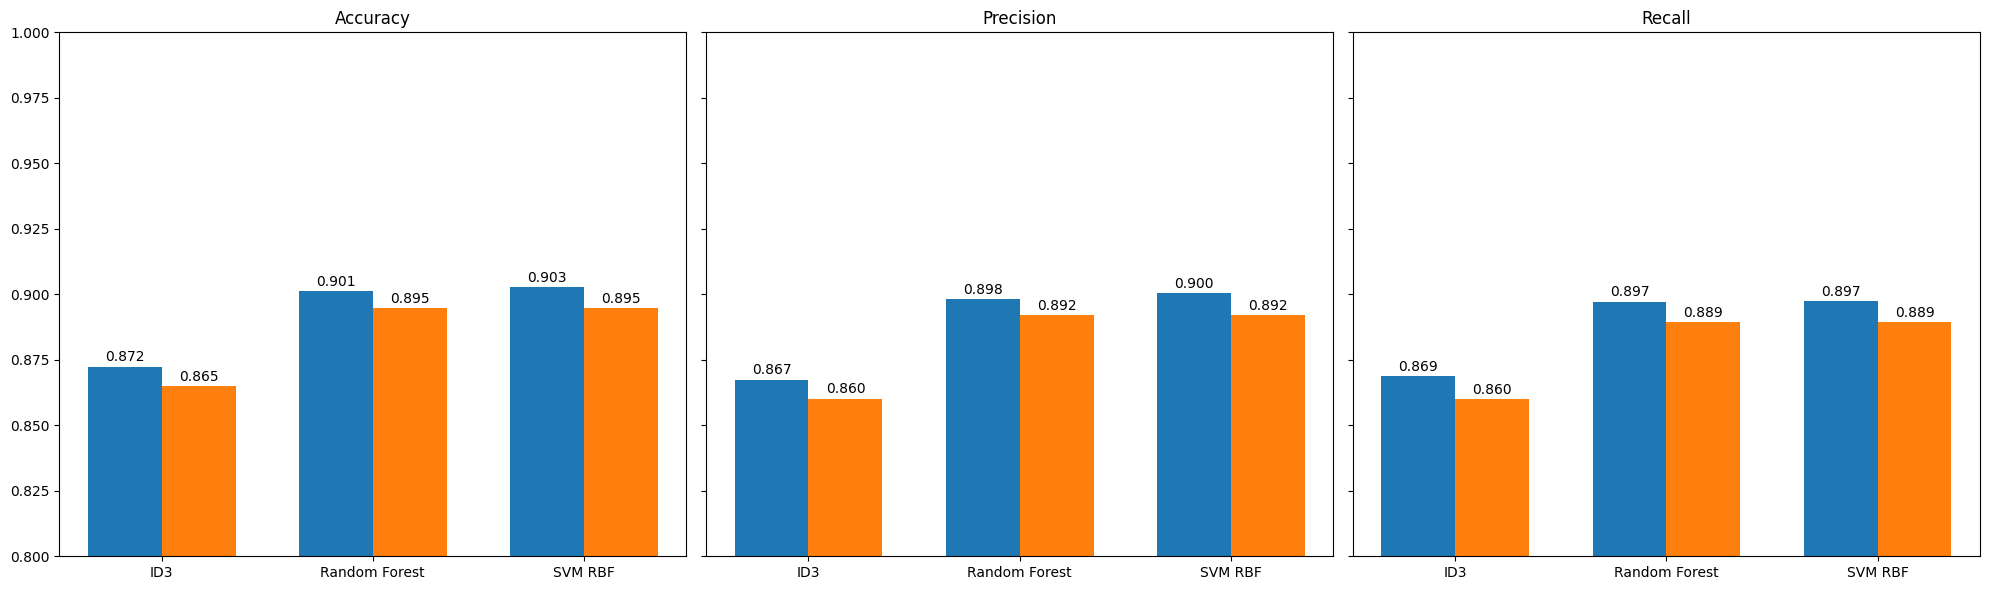

In [38]:
import matplotlib.pyplot as plt
import numpy as np

models = ["ID3", "Random Forest", "SVM RBF"]

# Extract metrics
train_acc = [id3_results["train"]["accuracy"], rf_results["train"]["accuracy"], svm_results["train"]["accuracy"]]
test_acc  = [id3_results["test"]["accuracy"],  rf_results["test"]["accuracy"],  svm_results["test"]["accuracy"]]

train_prec = [id3_results["train"]["precision"], rf_results["train"]["precision"], svm_results["train"]["precision"]]
test_prec  = [id3_results["test"]["precision"],  rf_results["test"]["precision"],  svm_results["test"]["precision"]]

train_rec = [id3_results["train"]["recall"], rf_results["train"]["recall"], svm_results["train"]["recall"]]
test_rec  = [id3_results["test"]["recall"],  rf_results["test"]["recall"],  svm_results["test"]["recall"]]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# accuracy
axes[0].bar(x - width/2, train_acc, width, label="Train")
axes[0].bar(x + width/2, test_acc, width, label="Test")
axes[0].set_title("Accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0.80, 1.00)

# value labels
for i, v in enumerate(train_acc):
    axes[0].text(i - width/2, v + 0.002, f"{v:.3f}", ha="center")
for i, v in enumerate(test_acc):
    axes[0].text(i + width/2, v + 0.002, f"{v:.3f}", ha="center")


# precision
axes[1].bar(x - width/2, train_prec, width, label="Train")
axes[1].bar(x + width/2, test_prec, width, label="Test")
axes[1].set_title("Precision")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylim(0.80, 1.00)

for i, v in enumerate(train_prec):
    axes[1].text(i - width/2, v + 0.002, f"{v:.3f}", ha="center")
for i, v in enumerate(test_prec):
    axes[1].text(i + width/2, v + 0.002, f"{v:.3f}", ha="center")


# recall
axes[2].bar(x - width/2, train_rec, width, label="Train")
axes[2].bar(x + width/2, test_rec, width, label="Test")
axes[2].set_title("Recall")
axes[2].set_xticks(x)
axes[2].set_xticklabels(models)
axes[2].set_ylim(0.80, 1.00)

for i, v in enumerate(train_rec):
    axes[2].text(i - width/2, v + 0.002, f"{v:.3f}", ha="center")
for i, v in enumerate(test_rec):
    axes[2].text(i + width/2, v + 0.002, f"{v:.3f}", ha="center")




plt.tight_layout()
plt.show()


In In the relatively similar conditions, the algorithms performed very closely to each other. ID3 consistently reached the weakest results across all three metrics and clearly suffered from its simple structure. Random Forest and the SVM with RBF kernel were much more stable, with SVM achieving slightly higher values in most cases. The differences were small, but they showed that more advanced models can extract a bit more information from the data while still keeping overfitting under control.

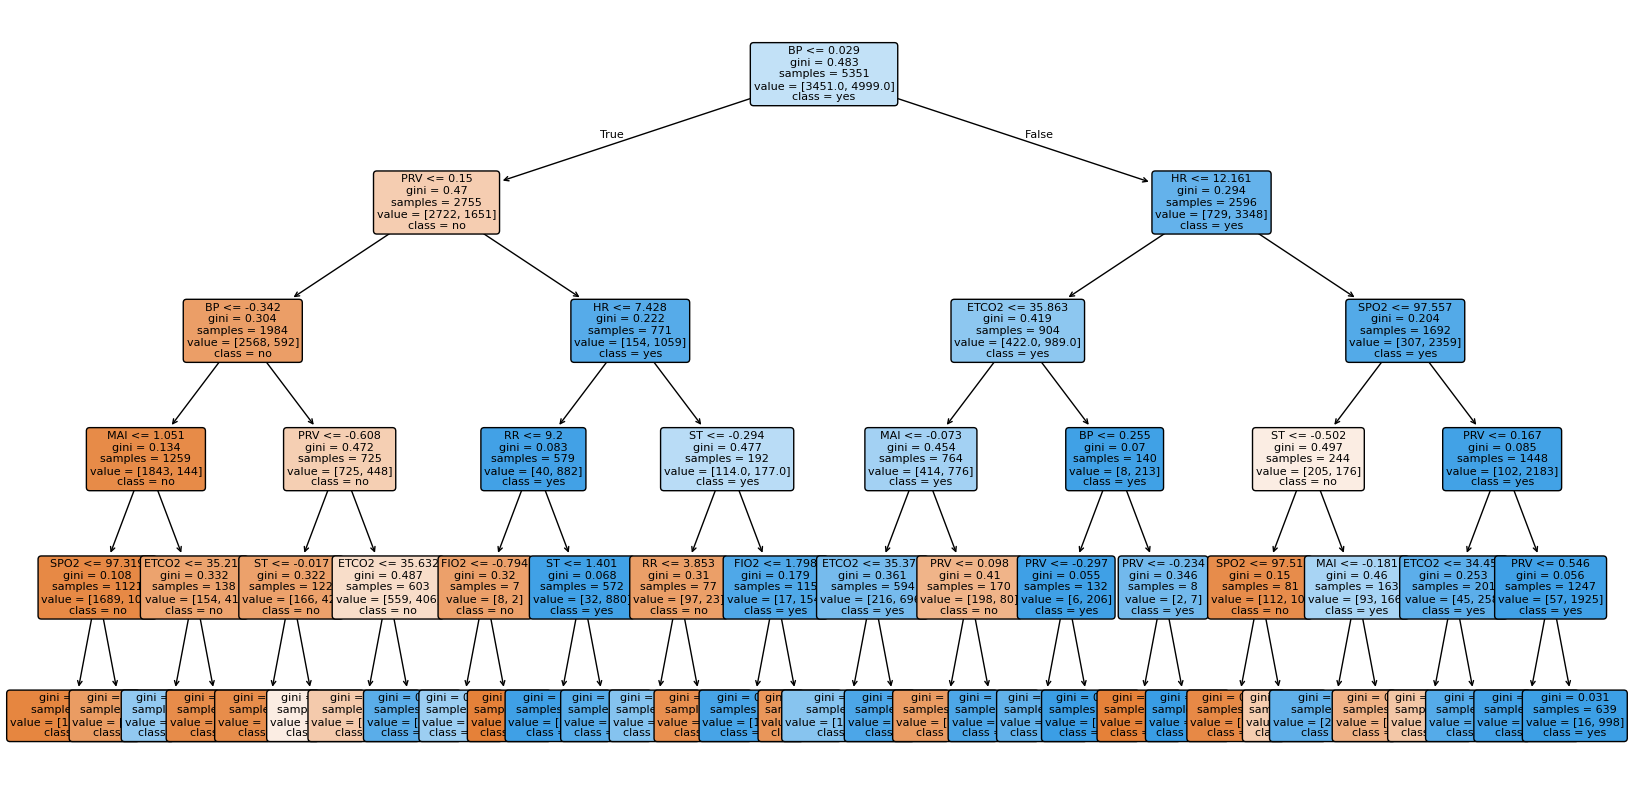

In [39]:
from sklearn.tree import plot_tree

tree = rf_model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    filled=True,
    feature_names=X.columns,
    class_names=['no', 'yes'],
    rounded=True,
    fontsize=8
)
plt.show()

Graph explain our random forrest model. It shows the set of rules the tree learned to separate the yes and no classes. The root node starts with BP, meaning this feature provided the strongest initial split. The left side of the tree quickly moves into very pure orange regions (class no), driven by thresholds on MAI, SPO2, ETCO2, and PRV, which clearly identify negative outcomes. The right side is mostly blue (class yes), with key splits on HR, ETCO2, and SPO2, suggesting these features were strongly associated with the positive class. Deeper nodes with higher gini values represent less certain regions, but that’s normal for individual trees. Overall, the tree highlights the most influential physiological variables and shows how Random Forest combines many such overfitted trees into a stable, generalisable model. Shame that leafs are not better visible but plot_tree and matplotlib do not have alternative option we could have use to make it more visible that we would have found.

# 3.3 Hyperparameter tuning for svc with kernel rbf

## Grid search

In [42]:
from sklearn import svm

estimator = svm.SVC(probability=True)

parameters = {
    'kernel':['rbf'], 
    'C': [0.1, 1, 3, 10], # penalizacia chyby
    'gamma': ['scale', 0.1, 0.01, 0.001], # ako velmi je hranica ohnuta
    'class_weight': [None, 'balanced']
    
}

scoring = ['accuracy', 
           'precision_micro']

clf = GridSearchCV(estimator=estimator, 
                   param_grid=parameters,
                   cv=5,
                   scoring=scoring,
                   refit='accuracy')

search = clf.fit(X_train_np, y_train)

#pprint(sorted(clf.cv_results_.keys()))
# print(search.best_estimator_)
# print(search.best_score_)
# print(search.best_params_)
# print(search.n_splits_)
#pprint(search.cv_results_)

## Best model evaluation

In [43]:
best_model = search.best_estimator_

y_pred_test = best_model.predict(X_test_np)
y_pred_train = best_model.predict(X_train_np)

print("TRAIN accuracy:", accuracy_score(y_train_np, y_pred_train))
print("TEST accuracy :", accuracy_score(y_test_np, y_pred_test))

print("Train Precision:", precision_score(y_train_np, y_pred_train))
print("Test Precision:", precision_score(y_test_np, y_pred_test))

print("Train Recall:", recall_score(y_train_np, y_pred_train))
print("Test Recall:", recall_score(y_test_np, y_pred_test))

print("Train F1:", f1_score(y_train_np, y_pred_train))
print("Test F1:", f1_score(y_test_np, y_pred_test))

print("Confusion matrix:\n", confusion_matrix(y_test_np, y_pred_test))

TRAIN accuracy: 0.9462721893491124
TEST accuracy : 0.9351187189398122
Train Precision: 0.9441090555014605
Test Precision: 0.9318592057761733
Train Recall: 0.9666999002991027
Test Recall: 0.9609120521172638
Train F1: 0.9552709359605911
Test F1: 0.9461626575028637
Confusion matrix:
 [[1322  151]
 [  84 2065]]


**Hyperparameter Tuning for SVC (kernel = RBF)**

To optimize model SVC we used method gredsearch which systematicaly explores the defined space of hyperparameters using 5-fold cross validation to pick the best model.

C ∈ {0.1, 1, 3, 10}
gamma ∈ {'scale', 0.1, 0.01, 0.001}
kernel = 'rbf'
class_weight ∈ {None, 'balanced'}

Corss validation ran only on train set. For each combination of hyperparameters the model was trained on 4 folds and validated on fifth. The resulting metrik is the average of validations.

The primary metroc we used accuracy because test classes are relatively balanced and accuracy supports good evaluation between models in grid search.

**The best model based on grid search:**

In [44]:
print(search.best_params_)

{'C': 10, 'class_weight': None, 'gamma': 0.1, 'kernel': 'rbf'}


**The best average CV score with 5 folds:**

In [45]:
print(search.best_score_)

0.9366863905325443


Hodnota 0.9367 znamená, že počas validácie dosiahol model priemernú presnosť 93.67 % naprieč všetkými foldmi.
Tento model bol následne použitý na predikciu na testovacej množine.

The value 0.9367 means that during validation the model achieved average accuracy 93.68% accross all folds. This model was used to predict the test set.


**Test results:**

In [46]:
print("TEST accuracy :", accuracy_score(y_test_np, y_pred_test))
print("Test Precision:", precision_score(y_test_np, y_pred_test))
print("Test Recall:", recall_score(y_test_np, y_pred_test))
print("Test F1:", f1_score(y_test_np, y_pred_test))
print("Confusion matrix:\n", confusion_matrix(y_test_np, y_pred_test))

TEST accuracy : 0.9351187189398122
Test Precision: 0.9318592057761733
Test Recall: 0.9609120521172638
Test F1: 0.9461626575028637
Confusion matrix:
 [[1322  151]
 [  84 2065]]


The difference between train and test set is less than 1.2% **which confirms that the model was not underfit nor overfitted and has great generalization**

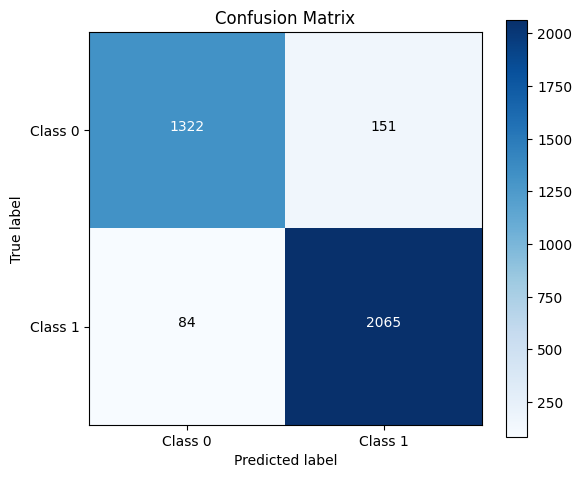

In [47]:
cm = confusion_matrix(y_test_np, y_pred_test)

classes = ["Class 0", "Class 1"]

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

# 3.3 B

In [48]:
best_svc = search.best_estimator_

rf_model = RandomForestClassifier(
    n_estimators=100,      
    max_depth=5,          
    min_samples_split=5,   
    min_samples_leaf=2,    
    random_state=42,
    n_jobs=-1              
)

# SOFT VOTING
ensemble_model = VotingClassifier(
    estimators=[
        ('svc', best_svc),
        ('rf', rf_model)
    ],
    voting='soft'
)

# train
ensemble_model.fit(X_train_np, y_train_np)

# pred
y_pred_test = ensemble_model.predict(X_test_np)
y_pred_train = ensemble_model.predict(X_train_np)

# metrics
print("Ensemble Train Accuracy:", accuracy_score(y_train_np, y_pred_train))
print("Ensemble Test Accuracy :", accuracy_score(y_test_np, y_pred_test))
print("Ensemble Train F1:", f1_score(y_train_np, y_pred_train))
print("Ensemble Test F1 :", f1_score(y_test_np, y_pred_test))


Ensemble Train Accuracy: 0.9429585798816568
Ensemble Test Accuracy : 0.9340143567090006
Ensemble Train F1: 0.9524279510461903
Ensemble Test F1 : 0.9451960559504701


We combined the best model found in grid search and the random forest classifier.

In terms of optimalization we created ensemble classificator using soft voting which combines two algorithm as we stated.

The target was to combine different models in order to have better generalization

Results of ensebled model:

Metric	    Train	Test
Accuracy	0.9429	0.9340
F1	        0.9524	0.9451

Ensembled achieves nearly similiar results as the best model SVC but a bit worse.
The reason is that RandomForest has lower prediction power than SVC.

However, ensemble is stable and generalize well and does not showcase any sign of overfitting.

# 3.4

## A
In data preperation we have merged two datasets, observations with stations based on foreign keys: longtitude and latitude. After we deleted location column, since we do not need another location which included nan values.

With the size of ~ 12000 the dataset was split into 70:30 for train and test data. With this amount of records we are able to provide sufficient amount of data to train and evaluate model. This split showedcased great generalization and accuracy on train and test data. The predicted value was slightly imbalanced (40 to 60) but the model was performing really well with no overfitting or underfitting we were not pushed to improve this imbalance.

Missing values were changed for the most frequent. However this might not be the best approach when we have too many missing data. But in our case we had only few missing codes. Thus using most frequent was the most efficient approach in terms of time.

The categorical data were encoded using either onehotencoder or leaveoneoutencoder. Creating sparse data but later applied feature selection reduced this sparsness and ensures that the model predicts efficiently.

Numerical data undergone soft winorization because the dataset had correct values and in reality it were correct measurements we couldnt clip it or delete it. Thus using winorization seemed as the best approach because we would not lose many data and wouldnt lose the correctness of the data.

This is the resulting data preprocessing with scaling and transformations:
```
preprocessor = ColumnTransformer(
    transformers=[
        ("winsor", winsorizer, list(WINSOR_METHODS.keys())), 
        ("num_standard", standard_numeric_pipeline, STANDARD_NUM),
        ("num_robust", robust_numeric_pipeline, ROBUST_NUM),
        ("num_power", power_numeric_pipeline, POWER_NUM),
        ("num_quantile", quantile_numeric_pipeline, QUANT_NUM), 
        ("lowcat", low_card_pipeline, LOW_CARD_CAT_COLS),
        ("highcat", high_card_pipeline, HIGH_CARD_CAT_COLS),
    ],
    remainder="drop"
)
```

# B
We used various types of scaling and transforming methods.

Why do we need scaling?

We used SVC with RBF kernel. This model calculates dissicion border based on distance. If one attribute has diff 0.1 - 0.9 and the other 10000 - 20000 the second attribute would dominante over the first one.

Results without scaling?
- SVC would not be able to find correct margin
- model would be chaotic
- overfitting
- optimalization is slow
- efficiency and accuracy is low

Decision trees and random forest does not need scaling because they do not use any distance calculations for determining something. It does not matter whether one attribute is only positive and the other one is negative because we always compare the attribute with the node with a number from the range. Also decision trees doesnt mind scaling, it is the same for them, since this is the case we use scaled data in decision trees and random forest. The scaling does not affect performance, logic, nothing. 

Why is transformation needed?
Each model needs imputation of nan values.
Encoding of categories. Since we use categoric data we need to encode them somehow.
We use SVC with kernel and like logistic regression or nn it assumes that the features are normal distributions. When the data are skewed, heavy tailed, or have outliers the SVC can not perform well.
In our case we use two types of transformers:
1. Power transformers - normalizes the skewenes, making it more normal

2. Quantile transformer - maps any distribution to normal

These transformation are heavily needed because we use SVC model which depends on normaly distributed data.

Also, transformations doesnt harm the trees therefore we use the same preprocessing and transformation for svc and id3, or randomforest.
For trees it is neutral.

If we took our best svc model and does not perform transformation nor scaling the best model and its results would look like this:

In [49]:
# PREPROCESSOR WITHOUT SCALING OR TRANSFORMATIONS

# NUMERIC PIPELINE – only imputing, NO scaling, NO transformations
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

# CATEGORICAL PIPELINES
low_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

high_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("leaveoneout", LeaveOneOutEncoder())
])

# ColumnTransformer WITHOUT power/quantile/scaling/winsor
preprocessor_no_transform = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, STANDARD_NUM + ROBUST_NUM + POWER_NUM + QUANT_NUM),
        ("lowcat", low_card_pipeline, LOW_CARD_CAT_COLS),
        ("highcat", high_card_pipeline, HIGH_CARD_CAT_COLS),
    ],
    remainder="drop"
)

preprocessed_selector_no_transform = Pipeline([
    ("preprocessing", preprocessor_no_transform),
    ("feature_selection", selector)
])

# fit-transform
X_train_processed = preprocessed_selector_no_transform.fit_transform(X_train, y_train)
X_test_processed  = preprocessed_selector_no_transform.transform(X_test)

# convert
X_train_np = X_train_processed.values if hasattr(X_train_processed, "values") else X_train_processed
y_train_np = y_train.values.ravel()

X_test_np = X_test_processed.values if hasattr(X_test_processed, "values") else X_test_processed
y_test_np = y_test.values.ravel()

# SVC WITHOUT TRANSFORMATIONS

from sklearn.svm import SVC

estimator = SVC(probability=True)

parameters = {
    'kernel':['rbf'], 
    'C': [0.1, 1, 3, 10],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'class_weight': [None, 'balanced']
}

scoring = ['accuracy', 'precision_micro']

clf = GridSearchCV(
    estimator=estimator, 
    param_grid=parameters,
    cv=5,
    scoring=scoring,
    refit='accuracy'
)

search = clf.fit(X_train_np, y_train_np)
best_model = search.best_estimator_

# predictions
y_pred_train = best_model.predict(X_train_np)
y_pred_test = best_model.predict(X_test_np)

# metrics
print(">>> RESULTS WITHOUT SCALING OR TRANSFORMATIONS <<<")
print("TRAIN accuracy:", accuracy_score(y_train_np, y_pred_train))
print("TEST accuracy :", accuracy_score(y_test_np, y_pred_test))

print("Train Precision:", precision_score(y_train_np, y_pred_train))
print("Test Precision:", precision_score(y_test_np, y_pred_test))

print("Train Recall:", recall_score(y_train_np, y_pred_train))
print("Test Recall:", recall_score(y_test_np, y_pred_test))

print("Train F1:", f1_score(y_train_np, y_pred_train))
print("Test F1:", f1_score(y_test_np, y_pred_test))

print("\nConfusion matrix:\n", confusion_matrix(y_test_np, y_pred_test))

print("\nBest params:", search.best_params_)
print("CV score:", search.best_score_)


>>> RESULTS WITHOUT SCALING OR TRANSFORMATIONS <<<
TRAIN accuracy: 0.8701775147928994
TEST accuracy : 0.8578133627829928
Train Precision: 0.8996328029375765
Test Precision: 0.8883079847908745
Train Recall: 0.8793619142572283
Test Recall: 0.8697068403908795
Train F1: 0.889381869516991
Test F1: 0.8789090054079474

Confusion matrix:
 [[1238  235]
 [ 280 1869]]

Best params: {'C': 10, 'class_weight': None, 'gamma': 0.001, 'kernel': 'rbf'}
CV score: 0.8611834319526628


We can clearly state that the transformation and scaling is necessary when using SVC with kernel RBF. The difference in accuracy is 8% +-

# C


### Feature Selection Analysis
We used multiple techniques to determine right feature selector for our model: tresholds from statistic tests(Variance, Mutual Information, F-test), wrappers() As a feature selection method, We used wrapper methods. As a model we used Random Forest model for its time efficiency. We reduce the atributes to reduce noise and time complexity because of redundant parameters which are not as relevant for the model.

### Choosing of algorithms
Firstly, we implemented id3 which however absolutely overfit and almost eveytime predicted just oximetry = 1. That model was built just for categorical data although we had entirely numeric in the dataset (after feauture selection). Therefore we needed treshold alteration of the algorithm. Then we used random forest model and support vector algoritm. The models reached similar results however the random forest model was significantly faster. The models were a lot more effective (around 3 more percent in accuracy) than id3  algoritms with the similar parameters. 


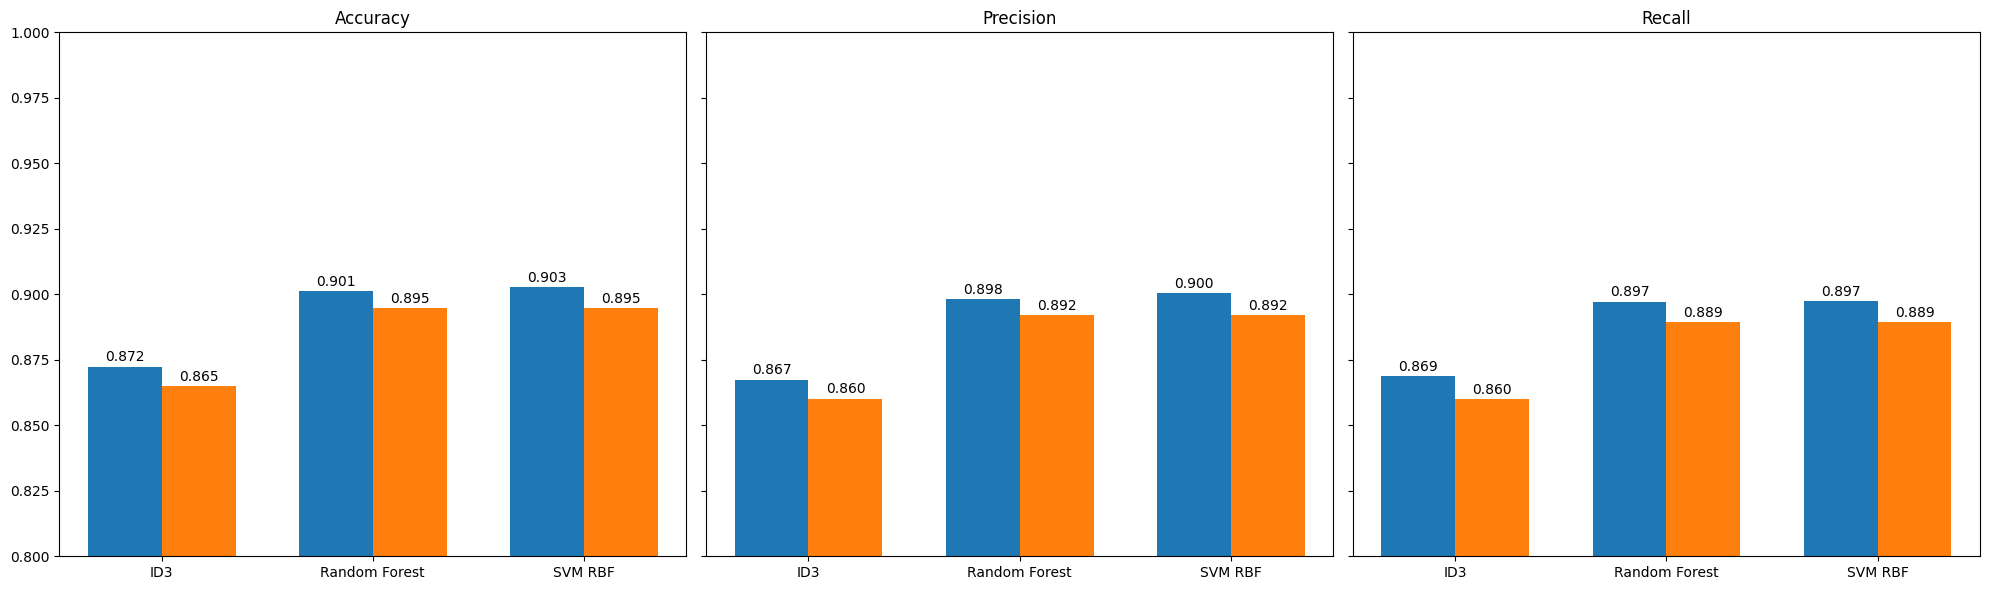

In [40]:
import matplotlib.pyplot as plt
import numpy as np

models = ["ID3", "Random Forest", "SVM RBF"]

# Extract metrics
train_acc = [id3_results["train"]["accuracy"], rf_results["train"]["accuracy"], svm_results["train"]["accuracy"]]
test_acc  = [id3_results["test"]["accuracy"],  rf_results["test"]["accuracy"],  svm_results["test"]["accuracy"]]

train_prec = [id3_results["train"]["precision"], rf_results["train"]["precision"], svm_results["train"]["precision"]]
test_prec  = [id3_results["test"]["precision"],  rf_results["test"]["precision"],  svm_results["test"]["precision"]]

train_rec = [id3_results["train"]["recall"], rf_results["train"]["recall"], svm_results["train"]["recall"]]
test_rec  = [id3_results["test"]["recall"],  rf_results["test"]["recall"],  svm_results["test"]["recall"]]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# accuracy
axes[0].bar(x - width/2, train_acc, width, label="Train")
axes[0].bar(x + width/2, test_acc, width, label="Test")
axes[0].set_title("Accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0.80, 1.00)

# value labels
for i, v in enumerate(train_acc):
    axes[0].text(i - width/2, v + 0.002, f"{v:.3f}", ha="center")
for i, v in enumerate(test_acc):
    axes[0].text(i + width/2, v + 0.002, f"{v:.3f}", ha="center")


# precision
axes[1].bar(x - width/2, train_prec, width, label="Train")
axes[1].bar(x + width/2, test_prec, width, label="Test")
axes[1].set_title("Precision")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylim(0.80, 1.00)

for i, v in enumerate(train_prec):
    axes[1].text(i - width/2, v + 0.002, f"{v:.3f}", ha="center")
for i, v in enumerate(test_prec):
    axes[1].text(i + width/2, v + 0.002, f"{v:.3f}", ha="center")


# recall
axes[2].bar(x - width/2, train_rec, width, label="Train")
axes[2].bar(x + width/2, test_rec, width, label="Test")
axes[2].set_title("Recall")
axes[2].set_xticks(x)
axes[2].set_xticklabels(models)
axes[2].set_ylim(0.80, 1.00)

for i, v in enumerate(train_rec):
    axes[2].text(i - width/2, v + 0.002, f"{v:.3f}", ha="center")
for i, v in enumerate(test_rec):
    axes[2].text(i + width/2, v + 0.002, f"{v:.3f}", ha="center")




plt.tight_layout()
plt.show()


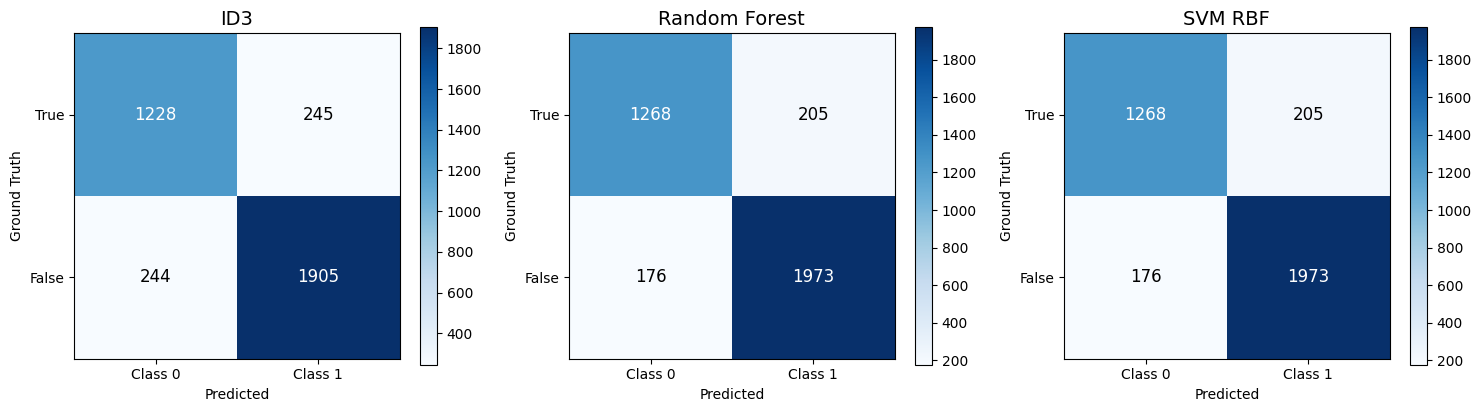

In [43]:
cm_id3 = id3_results["test"]["confusion"]
cm_rf = rf_results["test"]["confusion"]
cm_svm = svm_results["test"]["confusion"]

models = [
    ("ID3", cm_id3),
    ("Random Forest", cm_rf),
    ("SVM RBF", cm_svm)
]

plt.figure(figsize=(15, 4))

for i, (name, cm) in enumerate(models, 1):
    plt.subplot(1, 3, i)
    plt.imshow(cm, cmap="Blues", interpolation="nearest")
    plt.title(name, fontsize=14)
    plt.colorbar()

    plt.xticks([0, 1], ["Class 0", "Class 1"])
    plt.yticks([0, 1], ["True", "False"])
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")

    thresh = cm.max() / 2
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            plt.text(
                c, r, str(cm[r, c]),
                ha="center",
                va="center",
                fontsize=12,
                color="white" if cm[r, c] > thresh else "black"
            )

plt.tight_layout()
plt.show()

### Hyperparameter Tuning 

To find the optimal SVC configuration, we performed hyperparameter tuning using GridSearchCV with 5-fold cross-validation and accuracy as the main metric. The search confirmed that the best-performing setup was an RBF kernel with C=10 and gamma=0.1, which consistently delivered strong and well-balanced results. The difference between train and test accuracy stayed below 1.2 %, showing that the model generalised very well without signs of overfitting.

### Ensemble Conclusion
After tuning, we combined the best SVC model with a Random Forest classifier into a soft-voting ensemble to test whether mixing different learning principles could improve stability or predictive power. The ensemble reached performance close to the tuned SVC, but slightly worse, mainly because Random Forest contributed weaker predictions. Still, the ensemble remained stable, generalised reliably, and confirmed that combining models can serve as a robust fallback strategy even when it does not outperform the best single model.


# D
With all the right preprocessing and determining based on grid search we found out that the svc with rbf kernel works the best.

The tuned SVC displayed:
- excellent generalization ability,
- high predictive performance on both train and test sets,
- no signs of overfitting, and
- high stability across cross-validation folds.

Other models such as ID3, Random Forest, and the ensemble configuration were outperformed by the tuned SVC in accuracy, F1 score, and recall — which is especially important for a binary medical decision task.

**Performance Summary**

The final model achieved the following results:

- Train Accuracy: 0.9463
- Test Accuracy: 0.9351
- Train Precision: 0.9441
- Test Precision: 0.9319
- Train Recall: 0.9667
- Test Recall: 0.9609
- Train F1 Score: 0.9553
- Test F1 Score: 0.9462

These results demonstrate a train–test performance difference of less than 1.2%, confirming that the model neither overfits nor underfits and generalizes reliably to unseen data.

# E Data pipeline

To deploy the selected SVC model reliable in a production environment it is essential to reproduce the exact data processing and transformation steps used during training. This ensures that new data are handled consistently and the model receives inputes in the same structure and format as during development.

We expect that the production dataset involves, merged data from observation and station and that its columns are renamed.

Metadata in pipeline
- **DataCleaner**: cleaned station_df, rename map, dropped columns
- **Preprocessor**: imputation statistics, OHE categories, LeaveOneOut encoding mapping, winsor bounds, StandardScaler, RobustScaler, PowerTransformer, QuantileTransformer
- **Feature Selection**: top 10 features
- **SVC model**: {C=10, gamma=0.1, kernel='rbf'}

### Custom transformer, data cleaner

In [50]:
from sklearn.base import BaseEstimator, TransformerMixin

class DataCleaner(BaseEstimator, TransformerMixin):
    """
    Custom sklearn transformer for merging, renaming, dropping columns
    and preparing the cleaned dataset for the ML pipeline.
    """
    def __init__(self, station_df):
        self.station_df = station_df.copy()

    def fit(self, X, y=None):
        # Clean station_df once
        df = self.station_df.copy()
        df = df.drop_duplicates(subset=['station', 'longitude', 'latitude', 'location'], keep='first')
        df = df.drop(columns=['revision'])
        self.cleaned_station_df_ = df
        return self

    def transform(self, X):
        X = X.copy()

        # Rename observation columns
        rename_map = {
            'SpO₂': 'SPO2',
            'EtCO₂': 'ETCO2',
            'FiO₂': 'FIO2',
            'Skin Temperature': 'ST',
            'Motion/Activity index': 'MAI'
        }
        X = X.rename(columns={k: v for k, v in rename_map.items() if k in X.columns})

        # Merge datasets on longitude + latitude
        keys = ['longitude', 'latitude']
        df = pd.merge(X, self.cleaned_station_df_, on=keys, how='inner')

        # Drop columns not used for modeling
        if 'location' in df.columns:
            df = df.drop(columns=['location'])

        return df


In [51]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """
    Sklearn-compatible transformer for outlier clipping (winsorization),
    supporting per-column method selection (IQR or SD).
    """

    def __init__(self, methods_dict, sd_threshold=3, lower_pct=0.05, upper_pct=0.95, softness=0.99):
        """
        methods_dict: dict, e.g. {"HR": "SD", "SPO2": "IQR"}
        sd_threshold: cutoff for z-score when using SD
        lower_pct, upper_pct: quantile bounds used for soft winsorization
        softness: smoothing factor (0=no smoothing, 1=full)
        """
        self.methods_dict = methods_dict
        self.sd_threshold = sd_threshold
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct
        self.softness = softness

    def fit(self, X, y=None):
        """Compute winsorization bounds from TRAIN data only."""
        X = pd.DataFrame(X).copy()
        self.bounds_ = {}

        for col, method in self.methods_dict.items():
            data = X[col].dropna()
            if len(data) < 5:
                self.bounds_[col] = None
                continue

            # Hard bounds (IQR or SD)
            if method == "IQR":
                Q1, Q3 = data.quantile([0.25, 0.75])
                IQR = Q3 - Q1
                lower_hard = Q1 - 1.5 * IQR
                upper_hard = Q3 + 1.5 * IQR

            elif method == "SD":
                mean, std = data.mean(), data.std(ddof=1)
                lower_hard = mean - self.sd_threshold * std
                upper_hard = mean + self.sd_threshold * std

            else:
                raise ValueError(f"Unknown method {method}. Use 'IQR' or 'SD'.")

            # Soft clipping bounds
            lower_soft, upper_soft = data.quantile([self.lower_pct, self.upper_pct])

            self.bounds_[col] = {
                "lower_soft": lower_soft,
                "upper_soft": upper_soft,
                "lower_hard": lower_hard,
                "upper_hard": upper_hard
            }

        return self

    def transform(self, X):
        """Apply winsorization using bounds computed in fit()."""
        X = pd.DataFrame(X).copy()

        for col, bounds in self.bounds_.items():
            if bounds is None or col not in X.columns:
                continue

            ls, us = bounds["lower_soft"], bounds["upper_soft"]

            X[col] = np.where(
                X[col] < ls,
                ls + self.softness * (X[col] - ls),
                X[col]
            )
            X[col] = np.where(
                X[col] > us,
                us - self.softness * (us - X[col]),
                X[col]
            )

        return X


In [52]:
WINSOR_METHODS = {
    'SPO2': 'IQR',
    'HR': 'SD',
    'PI': 'IQR',
    'RR': 'SD',
    'FIO2': 'SD',
    'ETCO2': 'IQR',
    'MAI': 'IQR',
    'PRV': 'SD',
    'BP': 'SD',
    'ST': 'SD',
    'CO': 'IQR',
    'PVI': 'SD',
    'Hb level': 'SD',
    'SV': 'IQR',
    'Blood Flow Index': 'SD',
    'PPG waveform features': 'SD',
    'Signal Quality Index': 'SD',
    'Respiratory effort': 'SD',
    'O₂ extraction ratio': 'IQR',
    'SNR': 'IQR',
    'latitude': 'IQR',
    'longitude': 'IQR'
}
winsorizer = Winsorizer(methods_dict=WINSOR_METHODS)

In [53]:
STANDARD_NUM = [
    'HR','RR','FIO2','PRV','BP','PVI','Hb level',
    'Blood Flow Index','PPG waveform features',
    'Signal Quality Index','Respiratory effort'
]

ROBUST_NUM = [
    'SPO2','PI','ETCO2','ST','MAI','SV','latitude','longitude'
]

POWER_NUM = ['CO']

QUANT_NUM = ['O₂ extraction ratio', 'SNR']

LOW_CARD_CAT_COLS = [
    'code'        # 107 levels
]

HIGH_CARD_CAT_COLS = [
    'station'     # 552 levels
]

In [54]:
# NUMERIC PIPELINES

from sklearn.impute import SimpleImputer
from category_encoders.leave_one_out import LeaveOneOutEncoder

standard_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

robust_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

power_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])

quantile_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("quantile", QuantileTransformer(output_distribution="normal", random_state=42)),
    ("scaler", StandardScaler())
])


# CATEGORICAL PIPELINES

low_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

high_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("leaveoneout", LeaveOneOutEncoder())
])



In [55]:
preprocessor = ColumnTransformer(
    transformers=[
        ("winsor", winsorizer, list(WINSOR_METHODS.keys())), 
        ("num_standard", standard_numeric_pipeline, STANDARD_NUM),
        ("num_robust", robust_numeric_pipeline, ROBUST_NUM),
        ("num_power", power_numeric_pipeline, POWER_NUM),
        ("num_quantile", quantile_numeric_pipeline, QUANT_NUM), 
        ("lowcat", low_card_pipeline, LOW_CARD_CAT_COLS),
        ("highcat", high_card_pipeline, HIGH_CARD_CAT_COLS),
    ],
    remainder="drop"
)

# Data pipe line

In [65]:
ml_pipeline = Pipeline([
    ("data_cleaning", DataCleaner(stations)),          # merge + rename + drop
    ("preprocessing", preprocessor),                   # imputing, winsor, encoding, scaling, transforms
    ("feature_selection", selector),                   # RandomForest SelectFromModel
    ("classifier", SVC(kernel='rbf', C=10, gamma=0.1, probability=True))   # final model
])

NameError: name 'DataCleaner' is not defined

# Training pipeline

In [ ]:
# load raw datasets
observations = pd.read_csv("001/observation.csv", sep="\t")
stations     = pd.read_csv("001/station.csv", sep="\t")

TARGET = "oximetry"

X_raw = observations.copy()
y_raw = observations[TARGET]

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.3, random_state=42, stratify=y_raw
)

# fit full pipeline
ml_pipeline.fit(X_train, y_train)

# evaluate
y_pred = ml_pipeline.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Test accuracy: 0.9351187189398122
Confusion matrix:
 [[1322  151]
 [  84 2065]]


# Save model

In [ ]:
import joblib
joblib.dump(ml_pipeline, "respiratory_pipeline.pkl")

['respiratory_pipeline.pkl']

# Production, here comes the observatio record

In [ ]:
pipeline = joblib.load("respiratory_pipeline.pkl")  

# Load pipeline
pipeline = joblib.load("respiratory_pipeline.pkl")

# Load raw observations
observations = pd.read_csv("001/observation.csv", sep="\t")

# Choose example row
row_id = 6523
new_data_df = observations.iloc[[row_id]].copy()

# Predict
prediction = pipeline.predict(new_data_df)[0]

# True label
true_value = observations.iloc[row_id]["oximetry"]

# Print results
print("Row:", row_id)
print("True label:     ", true_value)
print("Predicted label:", prediction)

if prediction == true_value:
    print("Prediction is CORRECT!")
else:
    print("Prediction is WRONG!")

Row: 6523
True label:      0.0
Predicted label: 0.0
Prediction is CORRECT.
